In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [5]:
uber14 = pd.read_csv("C:\\Users\\jeffr\\OneDrive\\Desktop\\motorq_hackathon_practice\\data\\raw\\uber_2014\\uber-raw-data-apr14.csv")
uber15 = pd.read_csv("C:\\Users\\jeffr\\OneDrive\\Desktop\\motorq_hackathon_practice\\data\\raw\\uber_2015\\uber-raw-data-janjune-15.csv")
#zones = pd.read_csv("C:\\Users\\jeffr\\OneDrive\\Desktop\\motorq_hackathon_practice\\data\\raw\\lookup\\taxi-zone-lookup.csv")

In [13]:
uber14.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [11]:

uber15.head()


,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90


In [15]:
uber14.info()
uber15.info()


<class 'pandas.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  str    
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  str    
dtypes: float64(2), str(2)
memory usage: 17.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 14270479 entries, 0 to 14270478
Data columns (total 4 columns):
 #   Column                Dtype
---  ------                -----
 0   Dispatching_base_num  str  
 1   Pickup_date           str  
 2   Affiliated_base_num   str  
 3   locationID            int64
dtypes: int64(1), str(3)
memory usage: 435.5 MB


Handling Multiple Uber 2014 Monthly Files

“All Uber 2014 monthly files were concatenated into a single dataset since they share identical schemas and represent the same pickup-level events across different months.”

In [16]:
import glob

files_2014 = glob.glob("C:\\Users\\jeffr\\OneDrive\\Desktop\\motorq_hackathon_practice\\data\\raw\\uber_2014\\*.csv")

uber14_all = pd.concat(
    (pd.read_csv(f) for f in files_2014),
    ignore_index=True
)


In [20]:
uber14_all.shape



(4534327, 4)

In [21]:
uber14_all.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [22]:
uber14_all.info()


<class 'pandas.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  str    
 1   Lat        float64
 2   Lon        float64
 3   Base       str    
dtypes: float64(2), str(2)
memory usage: 138.4 MB


“I convert the timestamp from string to a datetime type so that the data becomes time-aware.
Strings can’t be used for time-based operations, but datetime types allow me to extract hours, days, and perform proper time-series aggregation.”

In [24]:
uber14_all["Date/Time"] = pd.to_datetime(uber14_all["Date/Time"])
uber14_all["Date/Time"].dtype



dtype('<M8[us]')

In [26]:
uber14_all["hour"] = uber14_all["Date/Time"].dt.hour


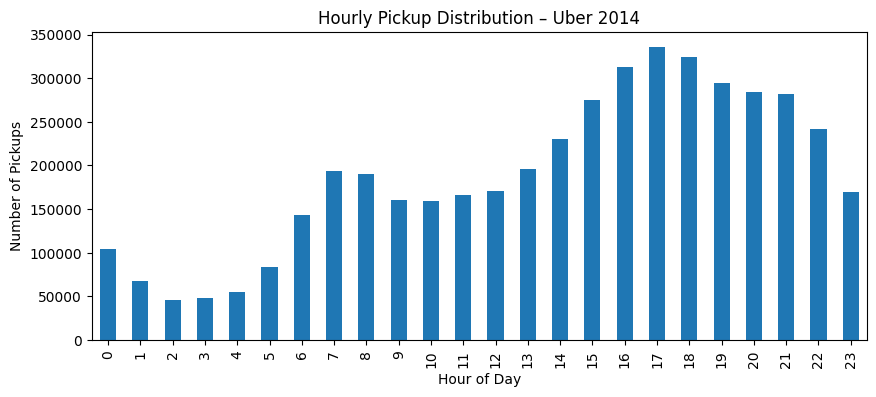

In [27]:
hourly_counts = uber14_all.groupby("hour").size()

hourly_counts.plot(kind="bar", figsize=(10,4))
plt.title("Hourly Pickup Distribution – Uber 2014")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.show()


reason why i plotted is  : “To validate whether time-of-day has a strong relationship with pickup demand."
“The hourly pickup distribution shows strong temporal patterns in demand. Demand is lowest during early morning hours (2–5 AM), rises sharply during morning commute hours, and peaks in the late afternoon and early evening around 5–6 PM. This aligns well with real-world commuting and travel behavior and indicates that time-of-day is a strong predictor of pickup demand. These patterns suggest clear opportunities for fleet operators to pre-position vehicles during peak hours to improve utilization and reduce customer wait times.”

In [28]:
uber14.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512
